In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, validation_curve,cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression, load_diabetes, make_blobs, load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
# Configuration globale des graphiques
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
np.random.seed(42)

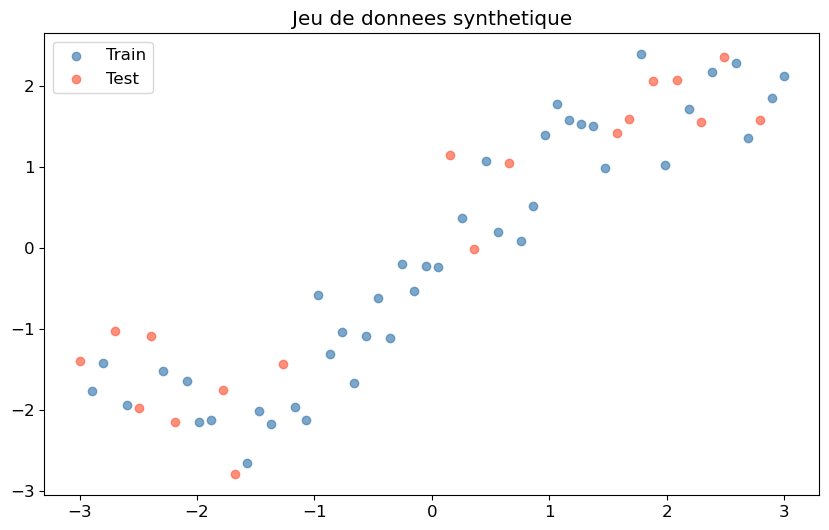

In [2]:
# Generation des donnees
n_samples = 60
X = np.linspace(-3, 3, n_samples).reshape(-1, 1)
y = np.sin(X.ravel()) + 0.5 * X.ravel() + np.random.normal(0, 0.5, n_samples)
# Separation train / test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)
# Visualisation
plt.scatter(X_train, y_train, label='Train', alpha=0.7, color='steelblue')
plt.scatter(X_test, y_test, label='Test', alpha=0.7, color='tomato')
plt.title('Jeu de donnees synthetique')
plt.legend()
plt.show()

In [3]:
def train_polynomial_model(degree, X_train, y_train, X_test, y_test):
    '''
    Entraîne un modèle de régression polynomiale de degré donné.
    Retourne (train_mse, test_mse)
    '''
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)), # Degré dynamique
        ('scaler', StandardScaler()),                # StandardScaler
        ('reg', LinearRegression())                  # LinearRegression
    ])
    
    model.fit(X_train, y_train)                      # Entraînement sur (X_train, y_train)
    
    train_mse = mean_squared_error(y_train, model.predict(X_train))
    test_mse = mean_squared_error(y_test, model.predict(X_test)) # Prédiction sur X_test
    
    return train_mse, test_mse
# Testez pour les degrés 1 à 10
degrees = list(range(1, 11))
train_errors, test_errors = [], []
for d in degrees:
    tr, te = train_polynomial_model(d, X_train, y_train, X_test, y_test)
    train_errors.append(tr)
    test_errors.append(te)

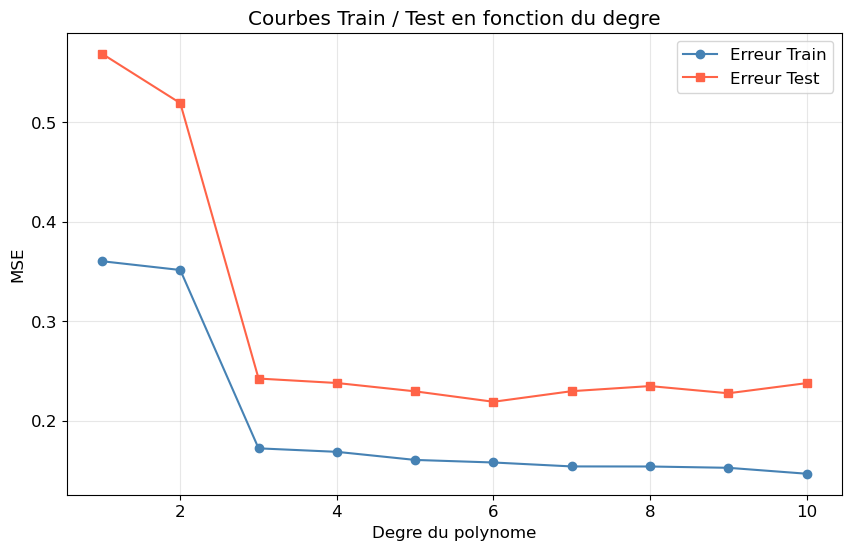

In [4]:
plt.plot(degrees, train_errors, 'o-', label='Erreur Train', color='steelblue')
plt.plot(degrees, test_errors, 's-', label='Erreur Test', color='tomato')
plt.xlabel('Degre du polynome')
plt.ylabel('MSE')
plt.title('Courbes Train / Test en fonction du degre')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

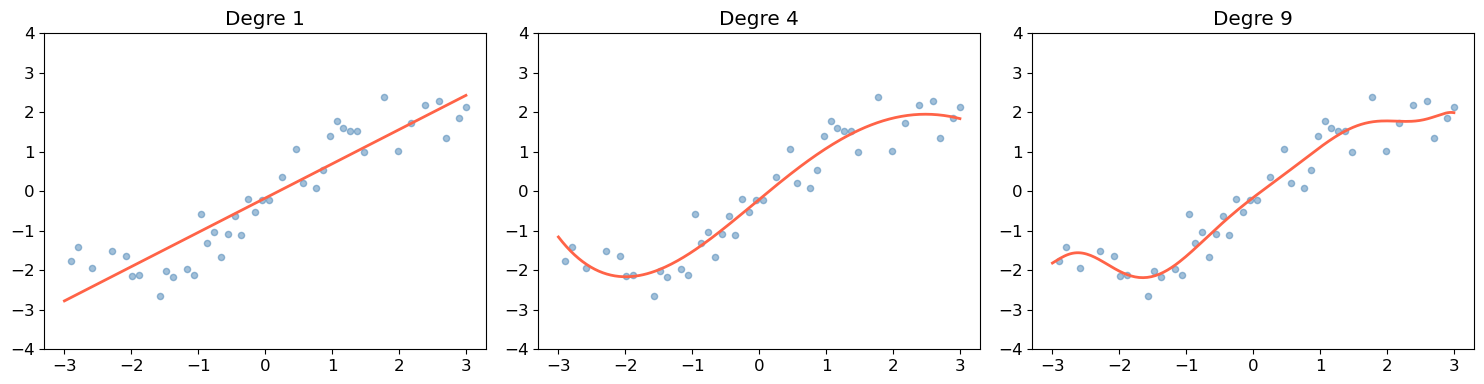

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
for ax, degree in zip(axes, [1, 4, 9]):
    model = Pipeline([
    ('poly', PolynomialFeatures(degree=degree)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_pred = model.predict(X_plot)
    ax.scatter(X_train, y_train, alpha=0.5, color='steelblue', s=20)
    ax.plot(X_plot, y_pred, color='tomato', lw=2)
    ax.set_title(f'Degre {degree}')
    ax.set_ylim(-4, 4)
plt.tight_layout()
plt.show()

In [6]:
# Chargement du dataset Diabetes (scikit-learn)
from sklearn.datasets import load_diabetes
data = load_diabetes()
X, y = data.data, data.target
# Noms des features
feature_names = data.feature_names
print('Features :', feature_names)
print('Dimensions :', X.shape)
# Split + normalisation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

Features : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Dimensions : (442, 10)


In [7]:
# TODO : completez ce tableau comparatif
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []
# Regression lineaire sans regularisation
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
mse_lr = mean_squared_error(y_test, lr.predict(X_test_sc))
results.append({'modele': 'LinearRegression', 'alpha': '-', 'MSE_test':
round(mse_lr, 2)})
for alpha in alphas_to_test:
    # Ridge
    ridge = Ridge(alpha=alpha) 
    ridge.fit(X_train_sc, y_train)
    mse_ridge = mean_squared_error(y_test, ridge.predict(X_test_sc))
    results.append({'modele': 'Ridge', 'alpha': alpha, 'MSE_test': round(mse_ridge, 2)})

    # Lasso
    lasso = Lasso(alpha=alpha) 
    lasso.fit(X_train_sc, y_train)
    mse_lasso = mean_squared_error(y_test, lasso.predict(X_test_sc))
    results.append({'modele': 'Lasso', 'alpha': alpha, 'MSE_test': round(mse_lasso, 2)})
import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.pivot(index='alpha', columns='modele', values='MSE_test'))

modele    Lasso  LinearRegression    Ridge
alpha                                     
0.01    2898.37               NaN  2900.08
0.1     2884.62               NaN  2899.05
1.0     2824.57               NaN  2892.01
10.0    2933.83               NaN  2875.78
100.0   5361.53               NaN  2858.22
-           NaN           2900.19      NaN


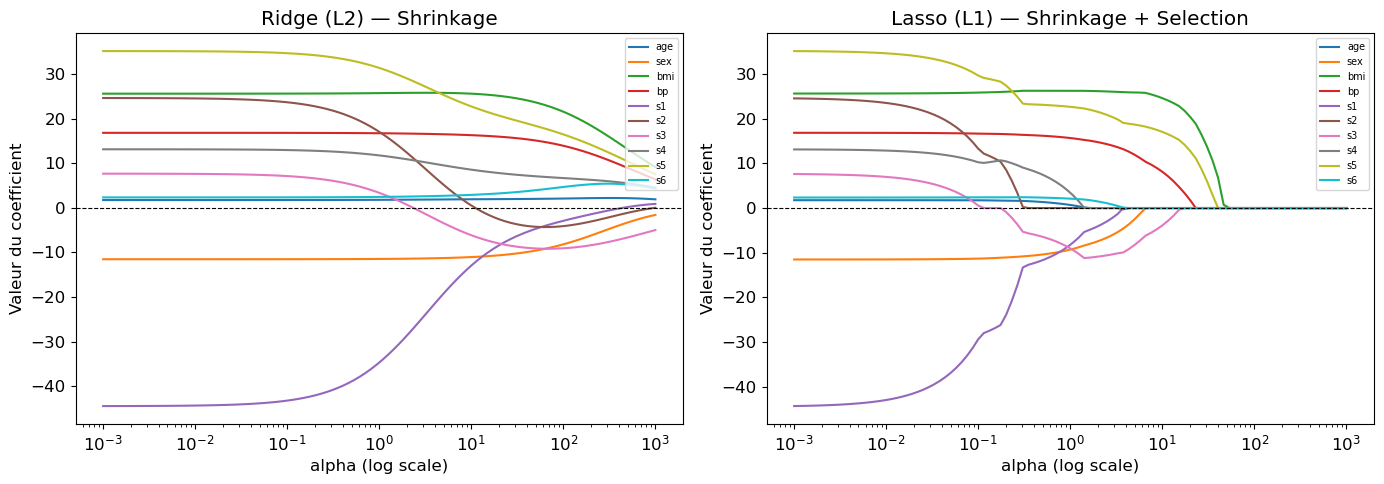

In [9]:
alphas = np.logspace(-3, 3, 100) 
coefs_ridge = [] 
coefs_lasso = [] 
  
for a in alphas: 
    r = Ridge(alpha=a).fit(X_train_sc, y_train) 
    coefs_ridge.append(r.coef_) 
    l = Lasso(alpha=a, max_iter=5000).fit(X_train_sc, y_train) 
    coefs_lasso.append(l.coef_) 
  
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) 
  
for i, name in enumerate(feature_names): 
    ax1.plot(alphas, [c[i] for c in coefs_ridge], label=name) 
    ax2.plot(alphas, [c[i] for c in coefs_lasso], label=name) 
  
for ax, title in zip([ax1, ax2], ['Ridge (L2) — Shrinkage', 'Lasso (L1) — Shrinkage + Selection']): 
    ax.set_xscale('log') 
    ax.set_xlabel('alpha (log scale)') 
    ax.set_ylabel('Valeur du coefficient') 
    ax.set_title(title) 
    ax.axhline(0, color='black', lw=0.8, ls='--') 
    ax.legend(fontsize=7, loc='upper right') 
plt.tight_layout() 
plt.show() 


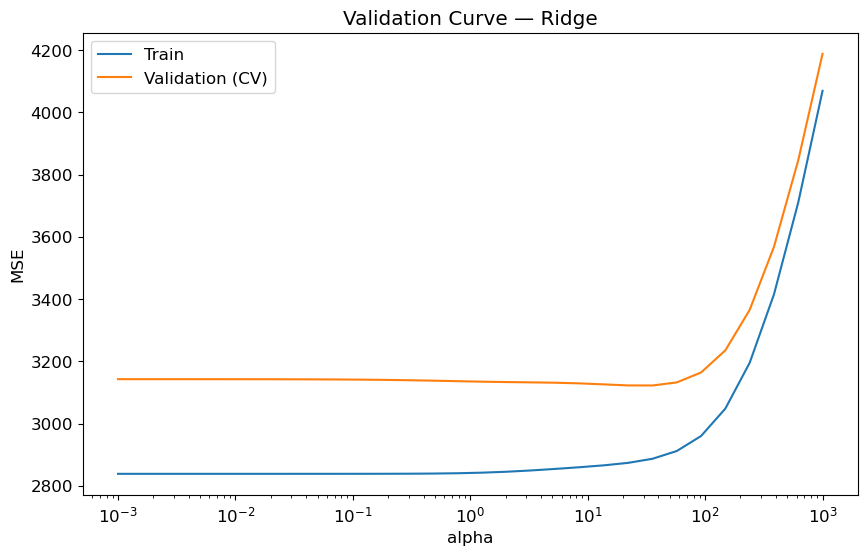

In [10]:
# TODO : tracez la validation curve pour Ridge 
# Indice : utilisez validation_curve de sklearn.model_selection 
alphas_vc = np.logspace(-3, 3, 30) 
train_scores, val_scores = validation_curve(
    Ridge(), # TODO modèle Ridge
    X_train_sc, y_train,
    param_name='alpha',
    param_range=alphas_vc,
    scoring='neg_mean_squared_error',
    cv=5
)
  
# Convertir en MSE positif 
train_mse_vc = -train_scores.mean(axis=1) 
val_mse_vc   = -val_scores.mean(axis=1) 
  
plt.plot(alphas_vc, train_mse_vc, label='Train') 
plt.plot(alphas_vc, val_mse_vc,   label='Validation (CV)') 
plt.xscale('log') 
plt.xlabel('alpha') 
plt.ylabel('MSE') 
plt.title('Validation Curve — Ridge') 
plt.legend() 
plt.show() 


In [14]:
from sklearn.model_selection import KFold, cross_val_score, cross_validate, GridSearchCV 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import StratifiedKFold 
  
# Dataset Diabetes 
from sklearn.datasets import load_diabetes 
data = load_diabetes() 
X, y = data.data, data.target 
  
scaler = StandardScaler() 
X_sc = scaler.fit_transform(X) 
  
# Definition du K-Fold 
kf = KFold(n_splits=5, shuffle=True, random_state=42) 
  
# Comparaison de 3 modeles 
models = { 
    'LinearRegression': LinearRegression(), 
    'Ridge(alpha=1)':   Ridge(alpha=1.0), 
    'Lasso(alpha=0.1)': Lasso(alpha=0.1), 
} 
  
for name, model in models.items():
    scores = cross_val_score(model, X_sc, y, cv=kf, scoring='neg_mean_squared_error') 
    mse_scores = -scores 
    print(f'{name:25s} | MSE moy = {mse_scores.mean():.1f} | std = {mse_scores.std():.1f}')


LinearRegression          | MSE moy = 3015.4 | std = 291.2
Ridge(alpha=1)            | MSE moy = 3012.7 | std = 282.7
Lasso(alpha=0.1)          | MSE moy = 3009.8 | std = 280.0


In [16]:
# TODO : utilisez cross_validate pour obtenir MSE et R² simultanement 
# cross_validate retourne un dictionnaire avec les scores train ET test 
  
results = cross_validate( 
    Ridge(alpha=1.0),                    # TODO : Ridge(alpha=1.0) 
    X_sc, y, 
    cv=kf,                # TODO : kf defini plus haut 
    scoring=['neg_mean_squared_error', 'r2'],            # TODO : ['neg_mean_squared_error', 'r2'] 
    return_train_score=True 
) 
  
  
print('MSE test  :', -results['test_neg_mean_squared_error'].mean().round(1)) 
print('R2  test  :',  results['test_r2'].mean().round(3)) 
print('MSE train :', -results['train_neg_mean_squared_error'].mean().round(1)) 
print('R2  train :',  results['train_r2'].mean().round(3)) 


MSE test  : 3012.7
R2  test  : 0.479
MSE train : 2844.5
R2  train : 0.52


Meilleur alpha : {'alpha': 0.1}
Meilleur MSE   : 2993.01


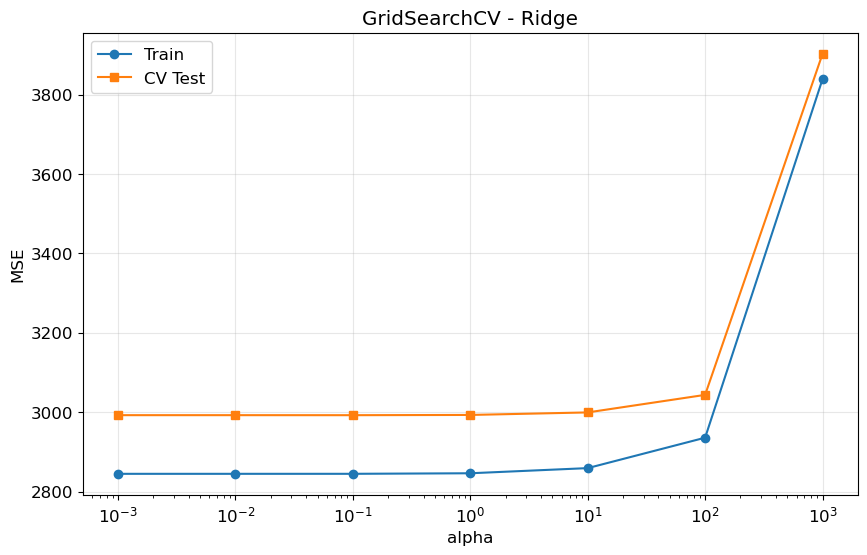

In [18]:
# TODO : trouvez le meilleur alpha pour Ridge par recherche sur grille 
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]} 
  
grid_search = GridSearchCV( 
    Ridge(),             # TODO : Ridge() 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error', 
    return_train_score=True 
) 
grid_search.fit(X_sc, y)   # TODO : X_sc, y 
  
print('Meilleur alpha :', grid_search.best_params_) 
print('Meilleur MSE   :', round(-grid_search.best_score_, 2)) 
  
# Visualisation 
results_gs = grid_search.cv_results_ 
alphas_gs  = param_grid['alpha'] 
plt.plot(alphas_gs, -results_gs['mean_train_score'], 'o-', label='Train') 
plt.plot(alphas_gs, -results_gs['mean_test_score'],  's-', label='CV Test') 
plt.xscale('log') 
plt.xlabel('alpha') 
plt.ylabel('MSE') 
plt.title('GridSearchCV - Ridge') 
plt.legend() 
plt.grid(True, alpha=0.3) 
plt.show()


In [19]:
from sklearn.model_selection import StratifiedKFold 
from sklearn.linear_model import LogisticRegression 
from sklearn.datasets import load_iris 
  
X_iris, y_iris = load_iris(return_X_y=True) 
X_iris_sc = StandardScaler().fit_transform(X_iris) 
  
# StratifiedKFold : chaque fold respecte la proportion des classes 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
  
scores = cross_val_score(LogisticRegression(max_iter=200), X_iris_sc, y_iris, 
                         cv=skf, scoring='accuracy') 
  
print(f'Accuracy par fold : {scores.round(3)}') 
print(f'Accuracy moyenne  : {scores.mean():.3f} (+/- {scores.std():.3f})') 


Accuracy par fold : [1.    0.967 0.9   1.    0.9  ]
Accuracy moyenne  : 0.953 (+/- 0.045)


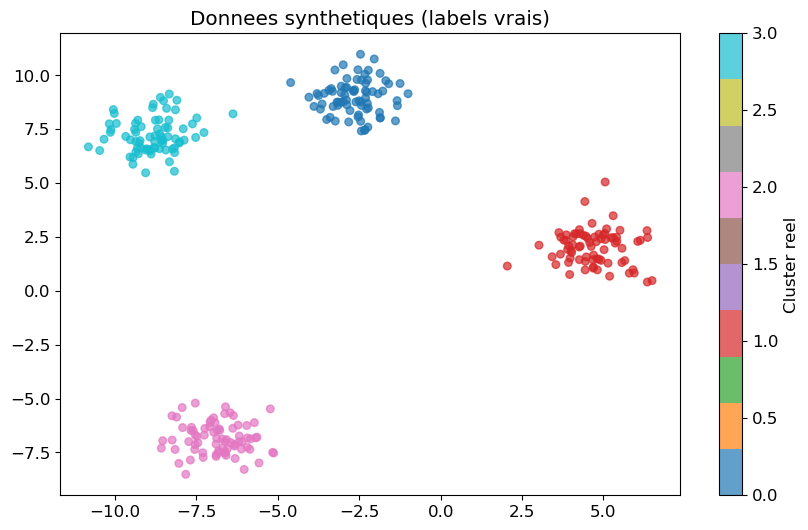

In [20]:
# Generation de donnees avec 4 clusters 
X_blob, y_true = make_blobs( 
    n_samples=300, 
    centers=4, 
    cluster_std=0.8, 
    random_state=42 
) 
  
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_true, cmap='tab10', alpha=0.7, s=30) 
plt.title('Donnees synthetiques (labels vrais)') 
plt.colorbar(label='Cluster reel') 
plt.show()


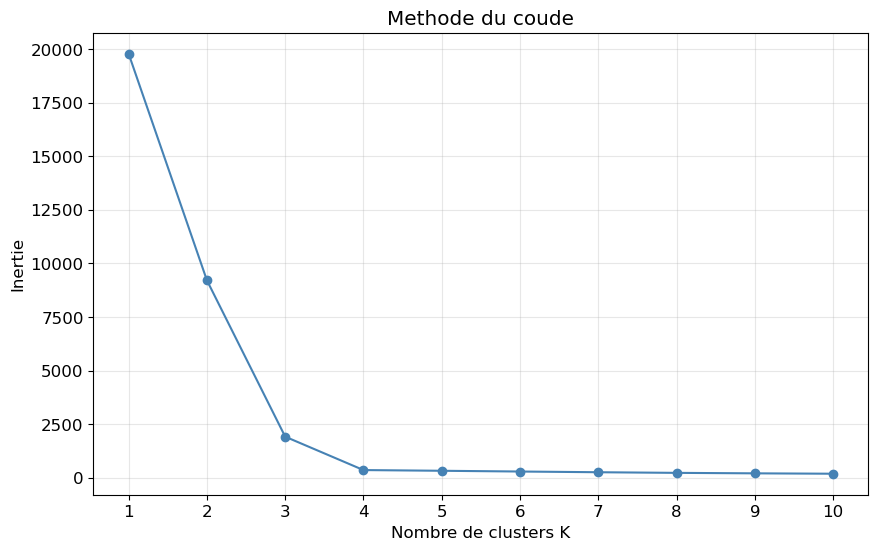

In [21]:
# TODO : calculez l'inertie pour K de 1 a 10 
K_range = range(1, 11) 
inertias = [] 
  
for k in K_range: 
    kmeans = KMeans(n_clusters=k, random_state=42)  # TODO 
    kmeans.fit(X_blob)                                   # TODO: X_blob 
    inertias.append(kmeans.inertia_)                              # TODO: attribut inertia_ 
# Tracez la courbe du coude 
plt.plot(K_range, inertias, 'o-', color='steelblue') 
plt.xlabel('Nombre de clusters K') 
plt.ylabel('Inertie') 
plt.title('Methode du coude') 
plt.xticks(K_range) 
plt.grid(True, alpha=0.3) 
plt.show() 


K=2 | Silhouette = 0.603
K=3 | Silhouette = 0.778
K=4 | Silhouette = 0.834
K=5 | Silhouette = 0.698
K=6 | Silhouette = 0.587
K=7 | Silhouette = 0.449
K=8 | Silhouette = 0.332


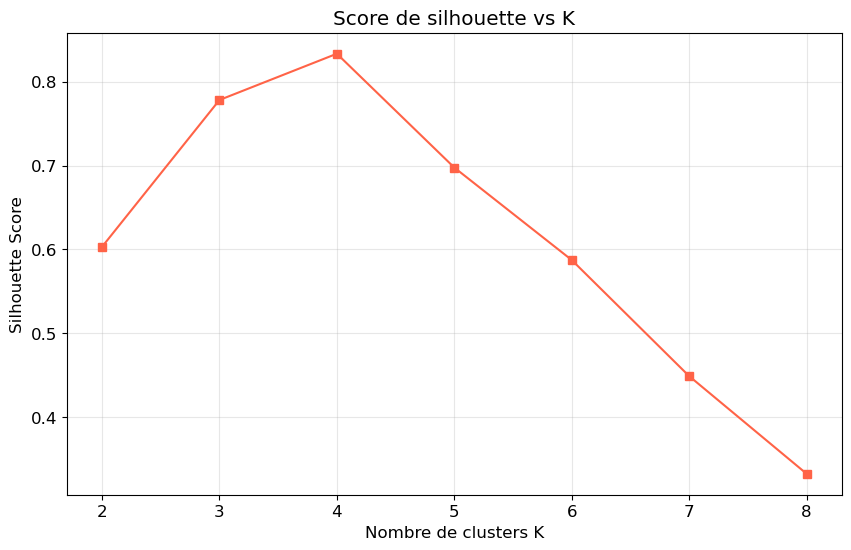

In [22]:
# TODO : calculez le silhouette score pour K de 2 a 8 
K_range_sil = range(2, 9) 
silhouette_scores = [] 
  
for k in K_range_sil: 
    kmeans = KMeans(n_clusters=k, random_state=42) 
    labels = kmeans.fit_predict(X_blob) 
    score = silhouette_score(X_blob, labels)  # TODO: donnees et labels 
    silhouette_scores.append(score) 
    print(f'K={k} | Silhouette = {score:.3f}') 
  
plt.plot(K_range_sil, silhouette_scores, 's-', color='tomato') 
plt.xlabel('Nombre de clusters K') 
plt.ylabel('Silhouette Score') 
plt.title('Score de silhouette vs K') 
plt.xticks(K_range_sil) 
plt.grid(True, alpha=0.3) 
plt.show() 


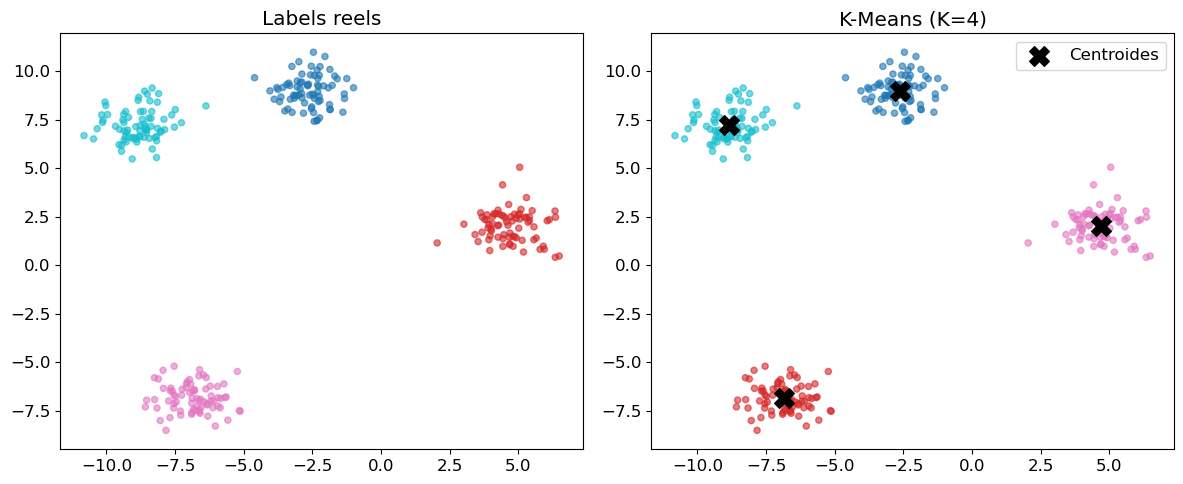

In [23]:
# Appliquez K-Means avec le K optimal trouve 
k_optimal = 4  # Remplacez par votre valeur 
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42) 
labels_pred = kmeans_final.fit_predict(X_blob) 
centroids   = kmeans_final.cluster_centers_ 
  
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) 
  
ax1.scatter(X_blob[:,0], X_blob[:,1], c=y_true,      cmap='tab10', alpha=0.6, 
s=20) 
ax1.set_title('Labels reels') 
  
ax2.scatter(X_blob[:,0], X_blob[:,1], c=labels_pred, cmap='tab10', alpha=0.6, 
s=20) 
ax2.scatter(centroids[:,0], centroids[:,1], c='black', marker='X', s=200, 
zorder=5, label='Centroides') 
ax2.set_title(f'K-Means (K={k_optimal})') 
ax2.legend() 
  
plt.tight_layout() 
plt.show() 


Variance expliquee : 95.8%


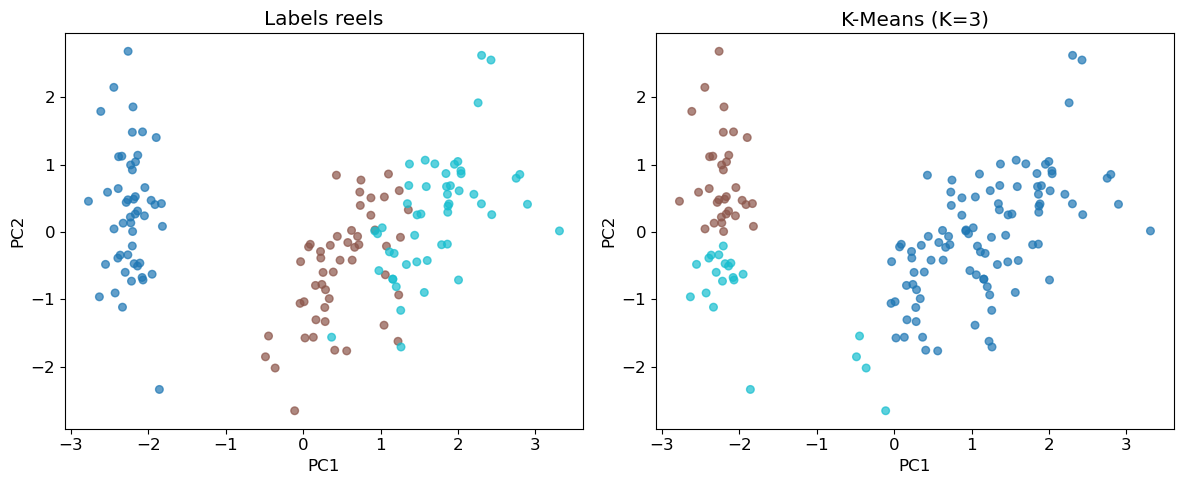

In [24]:
# TODO : appliquez K-Means sur le dataset Iris et visualisez avec PCA 
iris = load_iris() 
X_iris, y_iris = iris.data, iris.target 
  
# 1. Normalisez les donnees 
scaler_iris = StandardScaler() 
X_iris_sc =scaler_iris.fit_transform(X_iris)  # TODO 
  
# 2. Appliquez K-Means avec K=3 (3 especes d'iris) 
kmeans_iris = KMeans(n_clusters=3, random_state=42)  # TODO 
labels_iris = kmeans_iris.fit_predict(X_iris_sc) 
  
# 3. Reduisez a 2 dimensions avec PCA 
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_iris_sc) 
print(f'Variance expliquee : {pca.explained_variance_ratio_.sum():.1%}') 
  
# 4. Visualisez : labels predits vs labels reels (cote a cote) 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) 
for ax, labels, title in zip([ax1, ax2], [y_iris, labels_iris], 
                              ['Labels reels', 'K-Means (K=3)']): 
    ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='tab10', alpha=0.7, 
s=30) 
    ax.set_title(title) 
    ax.set_xlabel('PC1') 
    ax.set_ylabel('PC2') 
plt.tight_layout() 
plt.show() 
